In [1]:
import os
file = "2107_environment_data.csv"

import pandas as pd

df = pd.read_csv(file)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206008 entries, 0 to 206007
Data columns (total 4 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   measured_on                   206008 non-null  object 
 1   ambient_temperature_o_149575  205876 non-null  float64
 2   wind_speed_o_149576           205992 non-null  float64
 3   wind_direction_o_149577       206000 non-null  float64
dtypes: float64(3), object(1)
memory usage: 6.3+ MB


In [2]:
df.head()

,measured_on,ambient_temperature_o_149575,wind_speed_o_149576,wind_direction_o_149577
0,2017-12-01 00:00:00,38.8,1.2,156.0
1,2017-12-01 00:15:00,38.8,1.2,156.0
2,2017-12-01 00:30:00,38.8,1.2,156.0
3,2017-12-01 00:45:00,38.8,1.2,156.0
4,2017-12-01 01:00:00,37.0,2.6,247.0


In [3]:
df["measured_on"] = pd.to_datetime(df["measured_on"], yearfirst=True)
df.set_index("measured_on", inplace=True)
# Frecuencia explícita para statsmodels (datos cada 15 min)
df = df.asfreq(pd.infer_freq(df.index) or "15min")
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 207456 entries, 2017-12-01 00:00:00 to 2023-10-31 23:45:00
Freq: 15min
Data columns (total 3 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   ambient_temperature_o_149575  205876 non-null  float64
 1   wind_speed_o_149576           205992 non-null  float64
 2   wind_direction_o_149577       206000 non-null  float64
dtypes: float64(3)
memory usage: 6.3 MB


In [4]:
cols = df.columns
for n, col  in enumerate(cols):
    print(f"{n} - {col}")

0 - ambient_temperature_o_149575
1 - wind_speed_o_149576
2 - wind_direction_o_149577


In [5]:
cols = df.columns
cols
    

Index(['ambient_temperature_o_149575', 'wind_speed_o_149576',
       'wind_direction_o_149577'],
      dtype='object')

In [6]:
new_cols = ['ambient_temperature', 'wind_speed','wind_direction']
df.columns = new_cols
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 207456 entries, 2017-12-01 00:00:00 to 2023-10-31 23:45:00
Freq: 15min
Data columns (total 3 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ambient_temperature  205876 non-null  float64
 1   wind_speed           205992 non-null  float64
 2   wind_direction       206000 non-null  float64
dtypes: float64(3)
memory usage: 6.3 MB


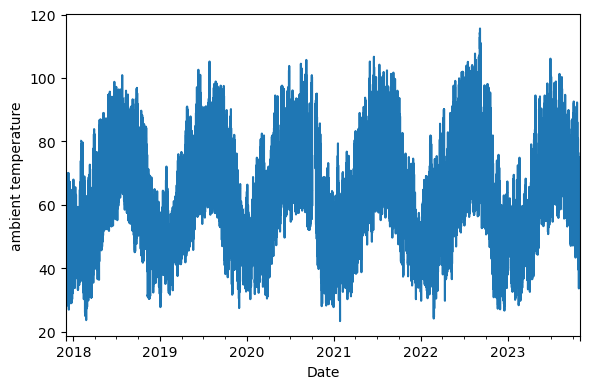

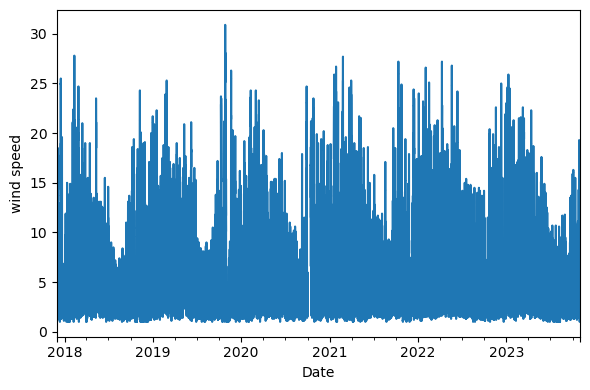

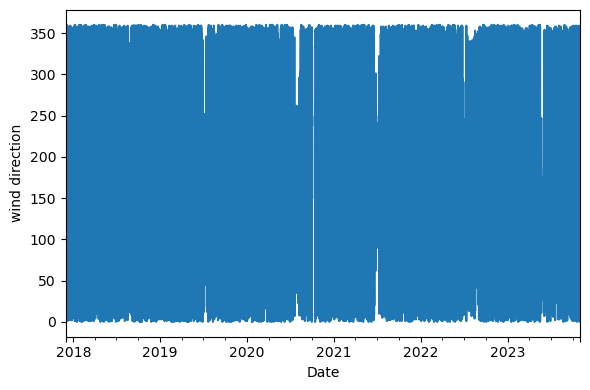

In [7]:
from matplotlib import pyplot as plt
cols = df.columns
for col in cols:
    plt.figure(figsize=(6, 4))
    df[col].resample("15min").mean().plot()
    plt.xlabel("Date")
    plt.ylabel(col.replace("_", " "))
    plt.tight_layout()
    plt.show()


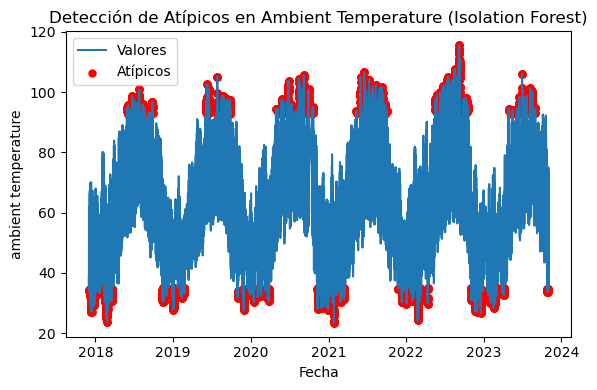

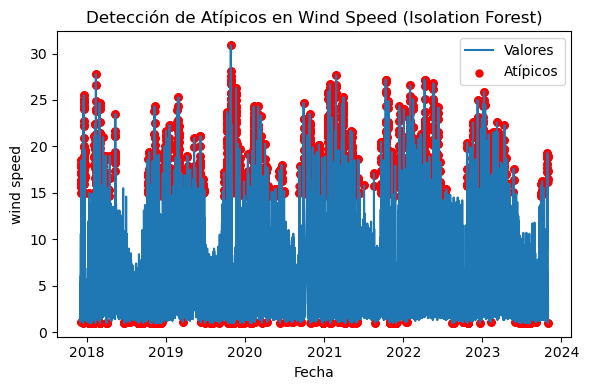

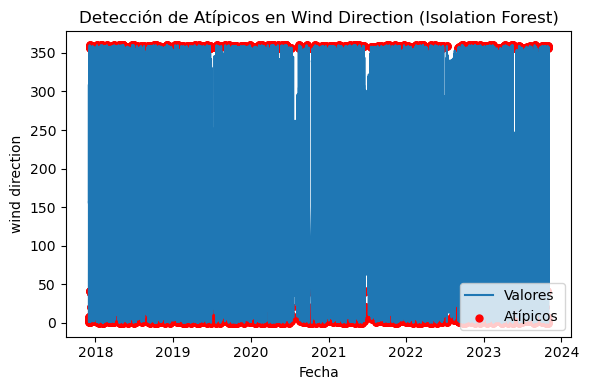

In [8]:
from sklearn.ensemble import IsolationForest

cols = df.columns

for col in cols:
    # IsolationForest expects 2D input
    data = df[[col]].dropna()
    model = IsolationForest(contamination=0.05, random_state=42)
    data["anomaly"] = model.fit_predict(data[[col]])
    # Atípicos: anomaly == -1
    outliers = data[data["anomaly"] == -1]
    
    plt.figure(figsize=(6, 4))
    plt.plot(data.index, data[col], label='Valores')
    plt.scatter(outliers.index, outliers[col], color='red', label='Atípicos', s=25)
    plt.xlabel("Fecha")
    plt.ylabel(col.replace("_", " "))
    plt.title(f"Detección de Atípicos en {col.replace('_', ' ').title()} (Isolation Forest)")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [9]:
# Quitar atípicos y rellenar con PMM (Predictive Mean Matching)

import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Primero, identificamos atípicos como previamente:
cols = df.columns
df_clean = df.copy()

for col in cols:
    # Entrenamos IsolationForest para cada columna
    data_col = df[[col]].dropna()
    model = IsolationForest(contamination=0.05, random_state=42)
    # El modelo espera datos 2D
    pred = model.fit_predict(data_col[[col]])
    # donde -1 indica un atípico
    outlier_idx = data_col.index[pred == -1]
    # Ponemos los atípicos como np.nan
    df_clean.loc[outlier_idx, col] = np.nan

# Ahora aplicamos IterativeImputer con el método "predictive mean matching"
imputer = IterativeImputer(random_state=42, sample_posterior=True, imputation_order='ascending', 
                          skip_complete=True, estimator=None, max_iter=10, initial_strategy='mean')
# PMM se usa por defecto con sample_posterior=True y estimador lineal

df_imputed = pd.DataFrame(
    imputer.fit_transform(df_clean),
    columns=cols,
    index=df_clean.index
)

# Sobreescribir df con datos imputados
df = df_imputed

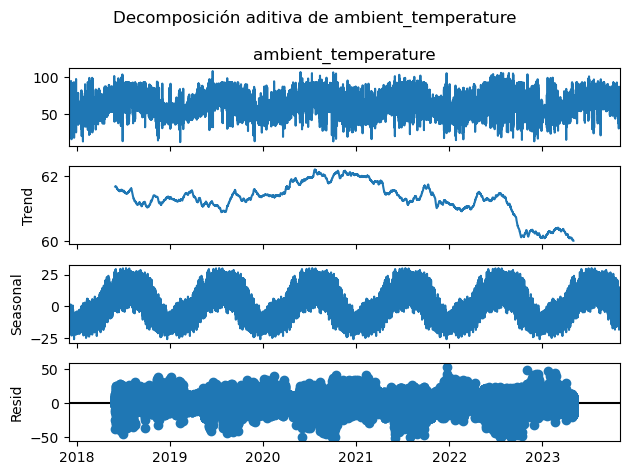

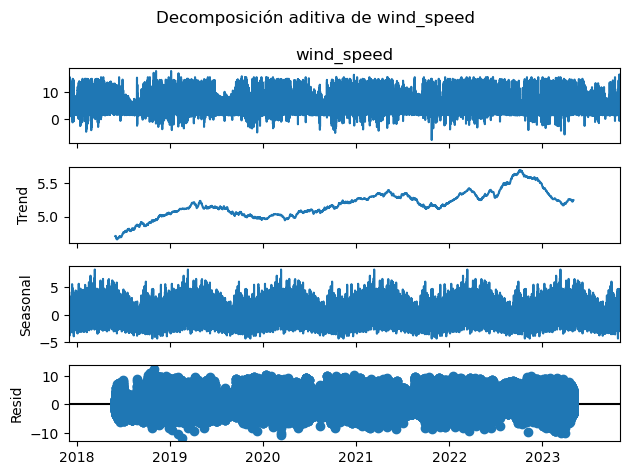

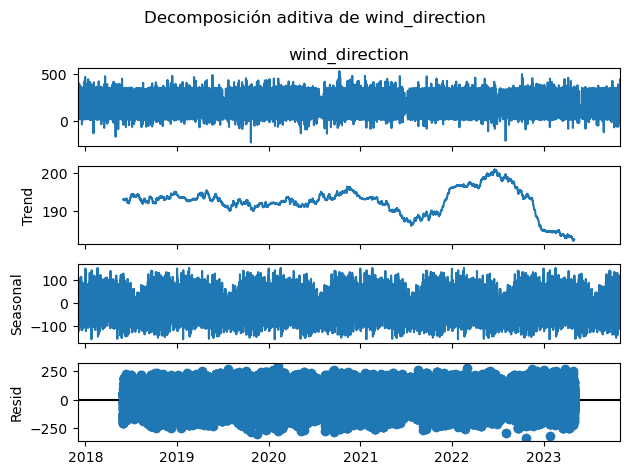

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib import pyplot as plt

# Seleccionamos las columnas para descomponer
for col in df.columns:
    # Asegúrate de que el índice es una serie temporal
    # Si el índice no es datetime, conviértelo (asume que measured_on está en el índice o conviértelo antes)
    ts = df[col]
    # Descomponer usando modelo aditivo
    result = seasonal_decompose(ts, model='additive', period=4*24*365)  # 96 períodos si los datos son 15 min (24*4)
    # Graficar la descomposición
    result.plot()
    plt.suptitle(f'Decomposición aditiva de {col}')
    plt.tight_layout()
    plt.show()


==== Suavizado exponencial para ambient_temperature ====


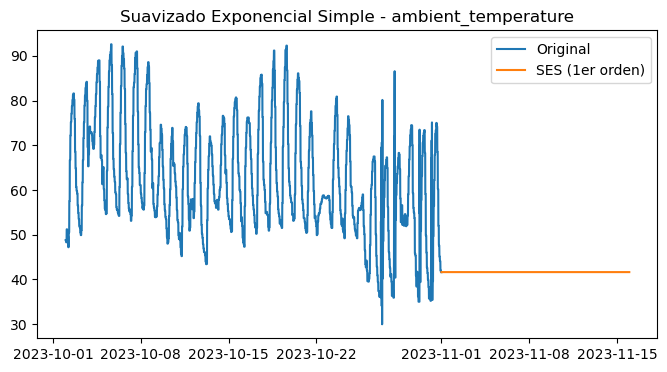

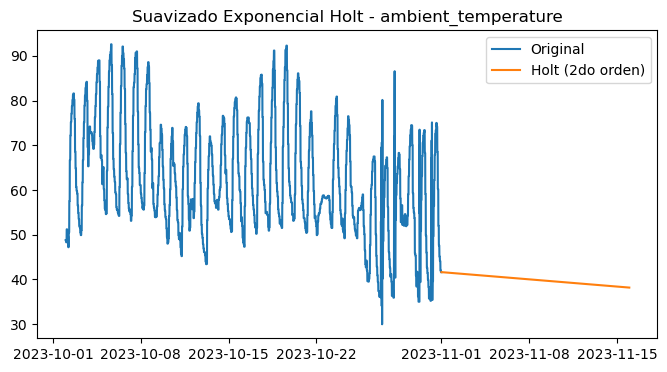

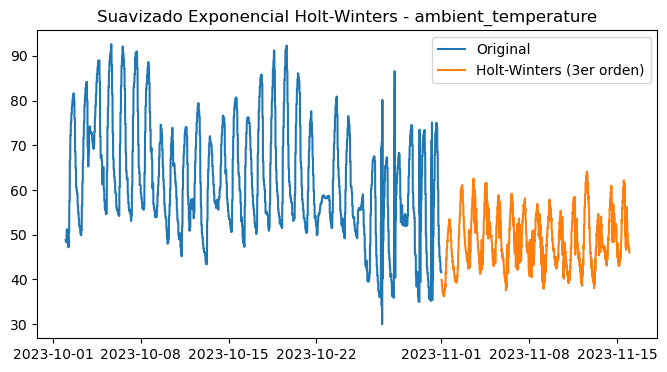


==== Suavizado exponencial para wind_speed ====


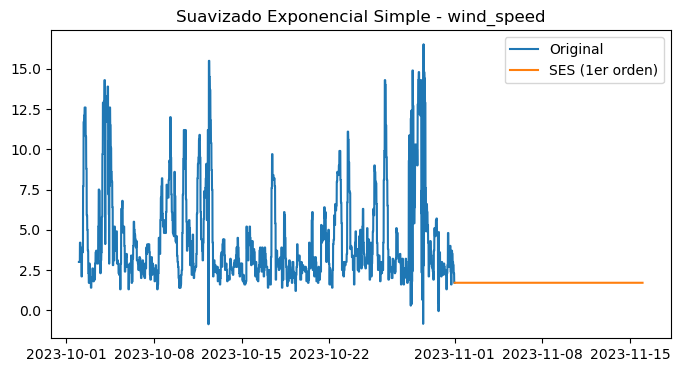

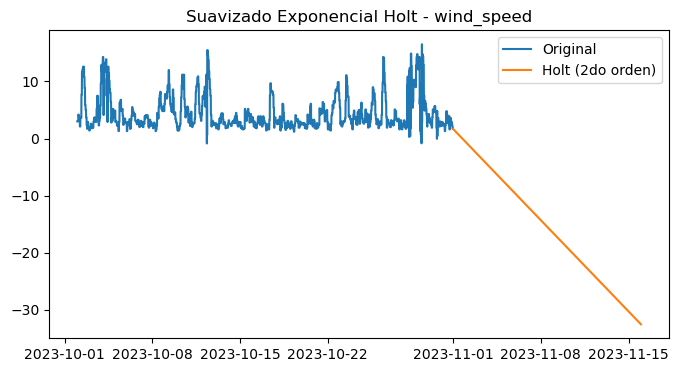

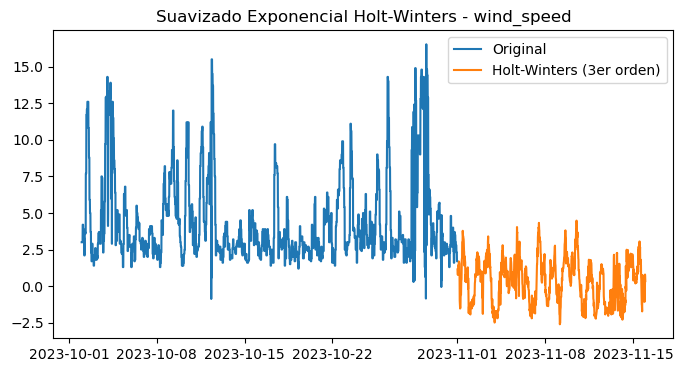


==== Suavizado exponencial para wind_direction ====


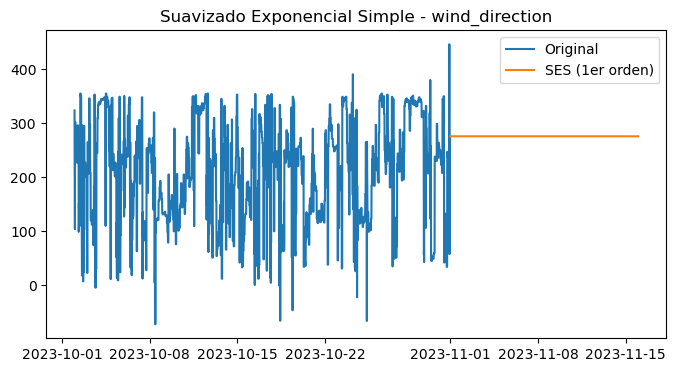

c:\Users\HISC\.conda\envs\dataMining\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


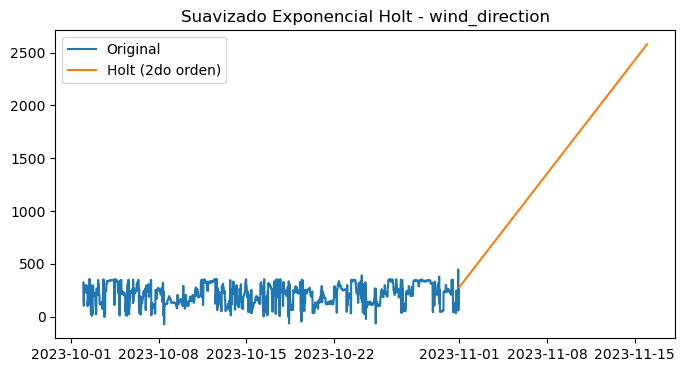

c:\Users\HISC\.conda\envs\dataMining\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


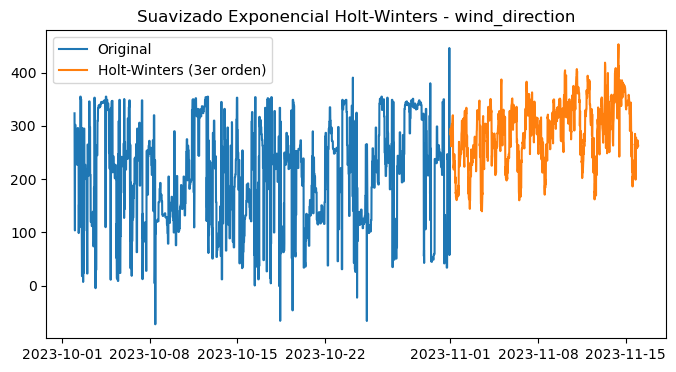

In [11]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
import numpy as np

# Selecciona la(s) columna(s) a predecir
target_cols = df.columns  # Puedes filtrar si quieres solo algunas

# Número de pasos a predecir (por ejemplo, una semana de datos de 15 minutos)
steps = 96 * 15

def get_freq_and_step(df_index):
    # Si ya es DatetimeIndex con freq, úsala
    if hasattr(df_index, 'freq') and df_index.freq is not None:
        return df_index.freq, None
    # Tratar de inferir frecuencia
    inferred = pd.infer_freq(df_index)
    if inferred is not None:
        return inferred, None
    # Si no puede inferir, calcular timedelta promedio
    if len(df_index) > 1:
        step = df_index[1] - df_index[0]
        return None, step
    return None, None

for col in target_cols:
    ts = df[col].dropna()
    if not isinstance(ts.index, pd.DatetimeIndex):
        raise ValueError("El índice de DataFrame debe ser DatetimeIndex para forecasting con fechas.")
    
    # Optimización de memoria
    if pd.api.types.is_float_dtype(ts):
        min_val = ts.min()
        max_val = ts.max()
        if min_val >= np.finfo(np.float32).min and max_val <= np.finfo(np.float32).max:
            ts = ts.astype(np.float32)
        elif min_val >= np.finfo(np.float16).min and max_val <= np.finfo(np.float16).max:
            ts = ts.astype(np.float16)
    elif pd.api.types.is_integer_dtype(ts):
        min_val = ts.min()
        max_val = ts.max()
        if min_val >= np.iinfo(np.int8).min and max_val <= np.iinfo(np.int8).max:
            ts = ts.astype(np.int8)
        elif min_val >= np.iinfo(np.int16).min and max_val <= np.iinfo(np.int16).max:
            ts = ts.astype(np.int16)
        elif min_val >= np.iinfo(np.int32).min and max_val <= np.iinfo(np.int32).max:
            ts = ts.astype(np.int32)

    freq, tdelta = get_freq_and_step(ts.index)
    last_date = ts.index[-1]
    if freq is not None:
        # pd.date_range con freq crea un DatetimeIndex CON información de frecuencia
        future_idx = pd.date_range(start=last_date + pd.tseries.frequencies.to_offset(freq), periods=steps, freq=freq)
    elif tdelta is not None:
        future_idx = pd.date_range(start=last_date + tdelta, periods=steps, freq=tdelta)
    else:
        future_idx = pd.RangeIndex(len(ts), len(ts) + steps)
    
    print(f"\n==== Suavizado exponencial para {col} ====")
    
    # SimpleExponentialSmoothing con ajuste de index para evitar ValueWarning/FutureWarning
    model_1 = SimpleExpSmoothing(ts, initialization_method="heuristic").fit(optimized=True)
    forecast_1 = model_1.forecast(steps)
    forecast_1.index = future_idx  # Asigna el índice de fechas correcto
    plt.figure(figsize=(8, 4))
    plt.plot(ts[-steps*2:], label='Original')
    plt.plot(forecast_1.index, forecast_1.values, label='SES (1er orden)')
    plt.legend()
    plt.title(f"Suavizado Exponencial Simple - {col}")
    plt.show()

    # Holt (nivel + tendencia)
    model_2 = ExponentialSmoothing(ts, trend='add', seasonal=None, initialization_method="heuristic").fit(optimized=True)
    forecast_2 = model_2.forecast(steps)
    forecast_2.index = future_idx
    plt.figure(figsize=(8, 4))
    plt.plot(ts[-steps*2:], label='Original')
    plt.plot(forecast_2.index, forecast_2.values, label='Holt (2do orden)')
    plt.legend()
    plt.title(f"Suavizado Exponencial Holt - {col}")
    plt.show()

    # Holt-Winters (nivel + tendencia + estacionalidad)
    try:
        model_3 = ExponentialSmoothing(ts, trend='add', seasonal='add', seasonal_periods=96*180, initialization_method="heuristic").fit(optimized=True)
        forecast_3 = model_3.forecast(steps)
        forecast_3.index = future_idx
        plt.figure(figsize=(8, 4))
        plt.plot(ts[-steps*2:], label='Original')
        plt.plot(forecast_3.index, forecast_3.values, label='Holt-Winters (3er orden)')
        plt.legend()
        plt.title(f"Suavizado Exponencial Holt-Winters - {col}")
        plt.show()
    except MemoryError:
        print(f"MemoryError: Reduce seasonal_periods para {col} o usa un dtype de menor tamaño si es posible.")

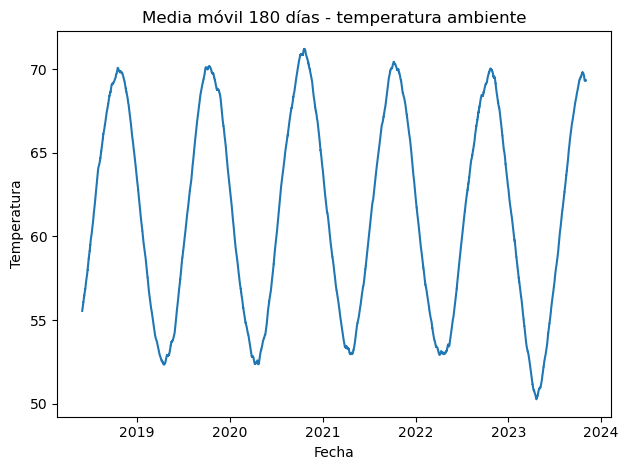

In [12]:
from matplotlib import pyplot as plt

plt.plot(df.iloc[:, 0].rolling(window=96 * 180).mean())
plt.title("Media móvil 180 días - temperatura ambiente")
plt.xlabel("Fecha")
plt.ylabel("Temperatura")
plt.tight_layout()
plt.show()

c:\Users\HISC\.conda\envs\dataMining\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



==== Pronóstico con Prophet para ambient_temperature ====
Puntos tras resample 2h: 25,932 (antes: 207,456)


13:37:53 - cmdstanpy - INFO - Chain [1] start processing
13:37:58 - cmdstanpy - INFO - Chain [1] done processing


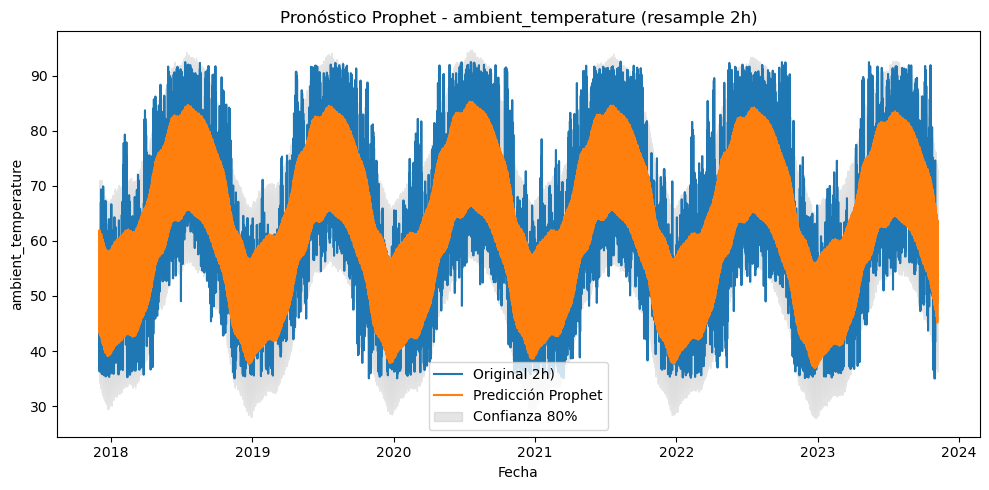


==== Pronóstico con Prophet para wind_speed ====
Puntos tras resample 2h: 25,932 (antes: 207,456)


13:38:05 - cmdstanpy - INFO - Chain [1] start processing
13:38:11 - cmdstanpy - INFO - Chain [1] done processing


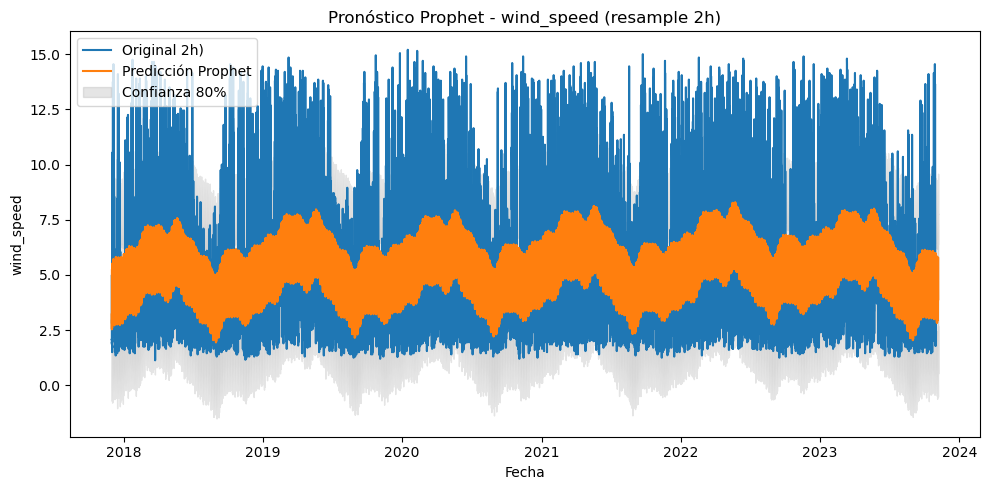


==== Pronóstico con Prophet para wind_direction ====
Puntos tras resample 2h: 25,932 (antes: 207,456)


13:38:17 - cmdstanpy - INFO - Chain [1] start processing
13:38:19 - cmdstanpy - INFO - Chain [1] done processing


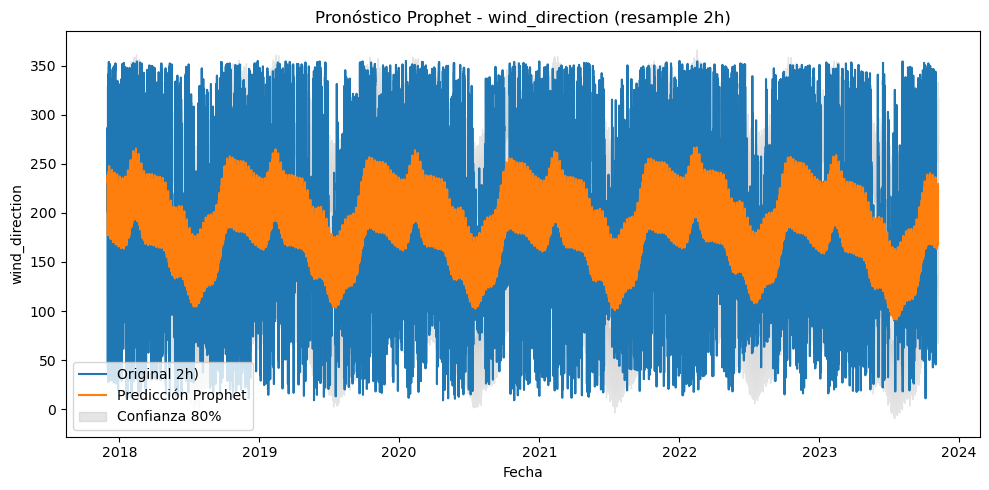

In [13]:
import os
import importlib.resources as importlib_resources
from pathlib import Path
import pandas as pd
from matplotlib import pyplot as plt

# Windows: prophet_model.bin requiere el tbb.dll empaquetado con Prophet
stan_model = Path(importlib_resources.files("prophet")) / "stan_model"
tbb_dlls = list(stan_model.rglob("tbb.dll"))
if tbb_dlls:
    os.environ["PATH"] = str(tbb_dlls[0].parent) + os.pathsep + os.environ.get("PATH", "")

from prophet import Prophet

for col in cols:
    print(f"\n==== Pronóstico con Prophet para {col} ====")
    ts_df = df[[col]].resample("2h").mean().dropna()
    print(f"Puntos tras resample 2h: {len(ts_df):,} (antes: {len(df):,})")
    ts_df = ts_df.rename(columns={col: "y"})
    ts_df["ds"] = ts_df.index
    ts_df["ds"] = pd.to_datetime(ts_df["ds"])

    m = Prophet()
    m.fit(ts_df)

    # 3 días de pronóstico a frecuencia horaria
    steps = 24 * 3
    future = m.make_future_dataframe(periods=steps, freq="2h")
    forecast = m.predict(future)

    plt.figure(figsize=(10, 5))
    plt.plot(ts_df["ds"], ts_df["y"], label="Original 2h)")
    plt.plot(forecast["ds"], forecast["yhat"], label="Predicción Prophet")
    plt.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"], color="gray", alpha=0.2, label="Confianza 80%")
    plt.legend()
    plt.title(f"Pronóstico Prophet - {col} (resample 2h)")
    plt.xlabel("Fecha")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


==== Pronóstico 1 año (valor máximo diario) con Prophet para ambient_temperature ====
Puntos tras resample diario: 2,161 (antes: 207,456)


13:38:24 - cmdstanpy - INFO - Chain [1] start processing
13:38:24 - cmdstanpy - INFO - Chain [1] done processing


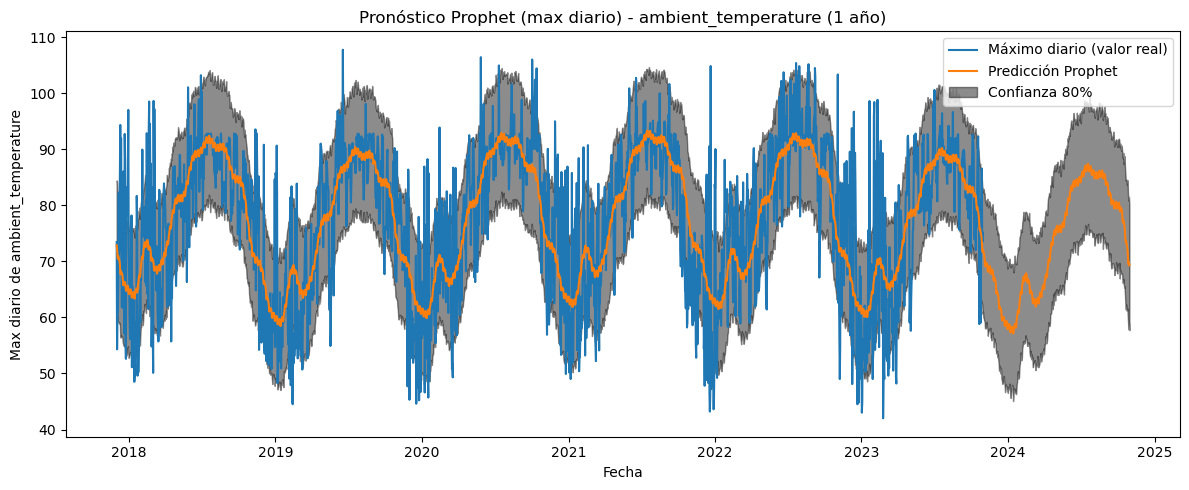


==== Pronóstico 1 año (valor máximo diario) con Prophet para wind_speed ====
Puntos tras resample diario: 2,161 (antes: 207,456)


13:38:25 - cmdstanpy - INFO - Chain [1] start processing
13:38:25 - cmdstanpy - INFO - Chain [1] done processing


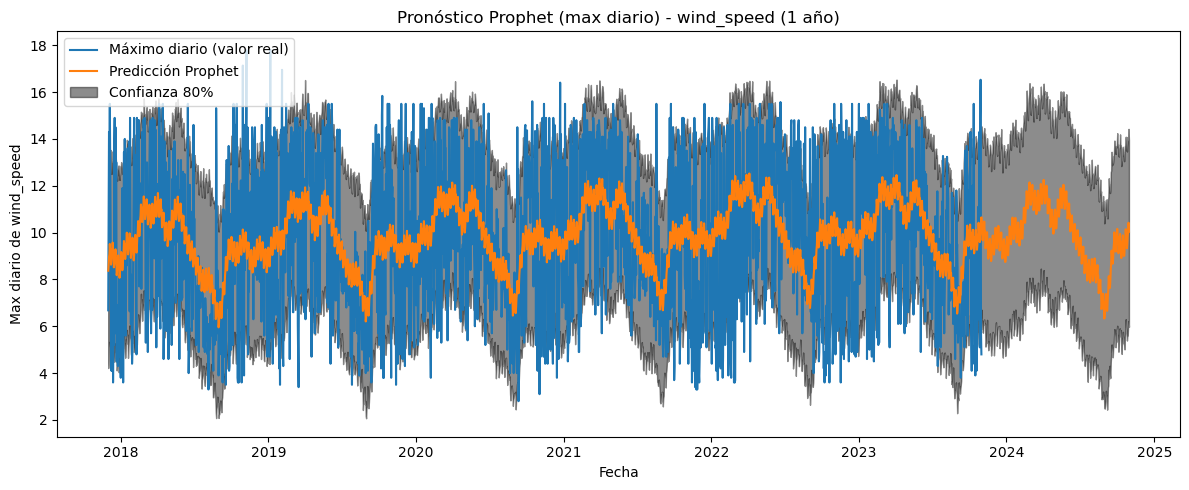


==== Pronóstico 1 año (valor máximo diario) con Prophet para wind_direction ====
Puntos tras resample diario: 2,161 (antes: 207,456)


13:38:26 - cmdstanpy - INFO - Chain [1] start processing
13:38:26 - cmdstanpy - INFO - Chain [1] done processing


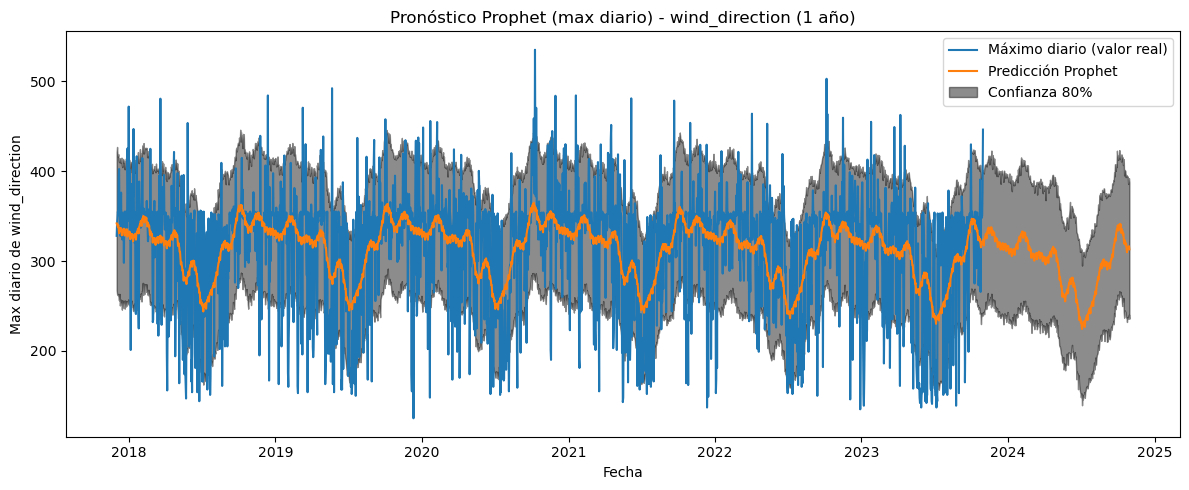

In [14]:
# Para cada variable, ajustar Prophet usando valor máximo diario y predecir el siguiente año

for col in cols:
    print(f"\n==== Pronóstico 1 año (valor máximo diario) con Prophet para {col} ====")
    # Resample: máximo diario
    ts_df = df[[col]].resample("D").max().dropna()
    print(f"Puntos tras resample diario: {len(ts_df):,} (antes: {len(df):,})")
    ts_df = ts_df.rename(columns={col: "y"})
    ts_df["ds"] = ts_df.index
    ts_df["ds"] = pd.to_datetime(ts_df["ds"])

    m = Prophet()
    m.fit(ts_df)

    # Un año de pronóstico a frecuencia diaria (365 días)
    steps = 365
    future = m.make_future_dataframe(periods=steps, freq="D")
    forecast = m.predict(future)

    plt.figure(figsize=(12, 5))
    plt.plot(ts_df["ds"], ts_df["y"], label="Máximo diario (valor real)")
    plt.plot(forecast["ds"], forecast["yhat"], label="Predicción Prophet")
    plt.fill_between(
        forecast["ds"], 
        forecast["yhat_lower"], 
        forecast["yhat_upper"], 
        color="black",       # más oscuras
        alpha=0.45,          # más opacidad
        label="Confianza 80%"
    )
    plt.legend()
    plt.title(f"Pronóstico Prophet (max diario) - {col} (1 año)")
    plt.xlabel("Fecha")
    plt.ylabel(f"Max diario de {col}")
    plt.tight_layout()
    plt.show()

### LSTM sin TensorFlow

La celda siguiente **ya ejecuta LSTM en NumPy** (no requiere TensorFlow).

**No ejecutes** `%pip install tensorflow` si tienes poco espacio en `C:` — el error sera:
`OSError: [Errno 28] No space left on device`.

TensorFlow necesita **al menos 3 GB libres**. Usa la ultima celda para comprobar espacio antes de instalar.



==== Pronóstico con LSTM para ambient_temperature ====
Puntos tras resample 1h: 51,864 (antes: 207,456)


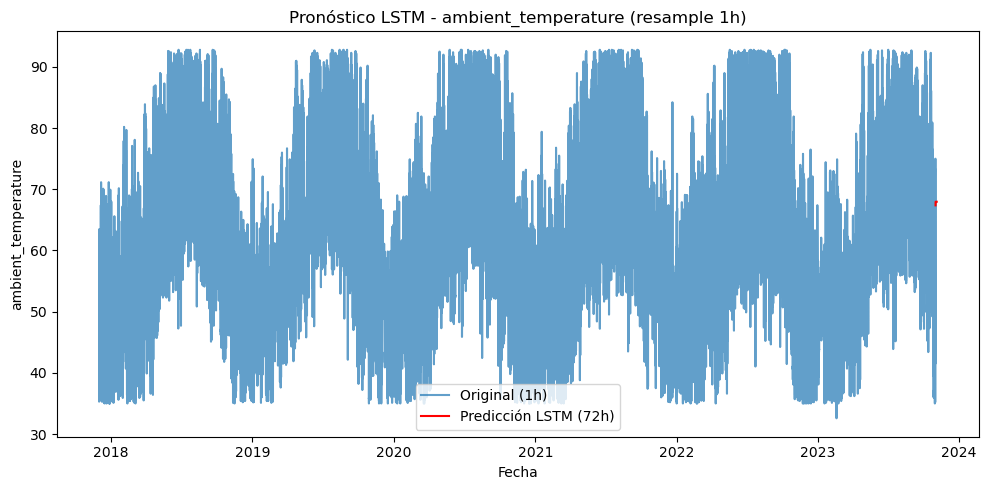


==== Pronóstico con LSTM para wind_speed ====
Puntos tras resample 1h: 51,864 (antes: 207,456)


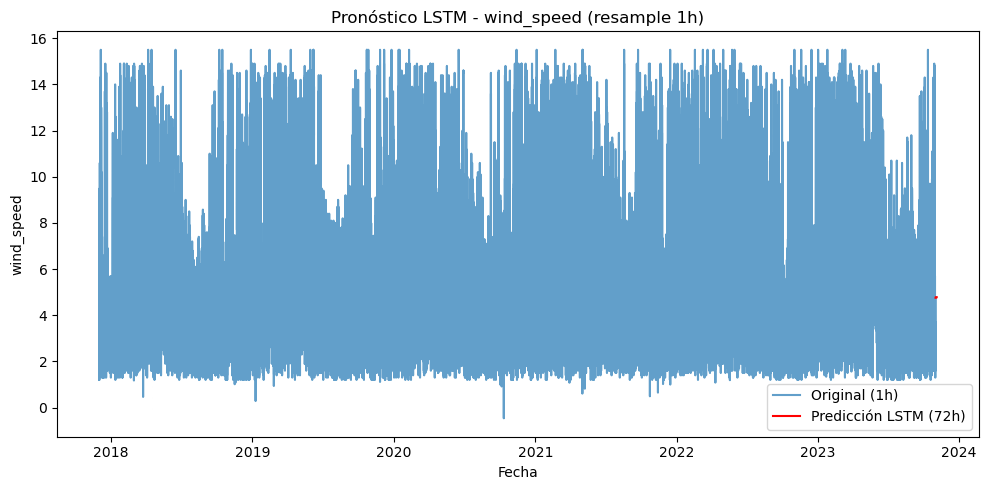


==== Pronóstico con LSTM para wind_direction ====
Puntos tras resample 1h: 51,864 (antes: 207,456)


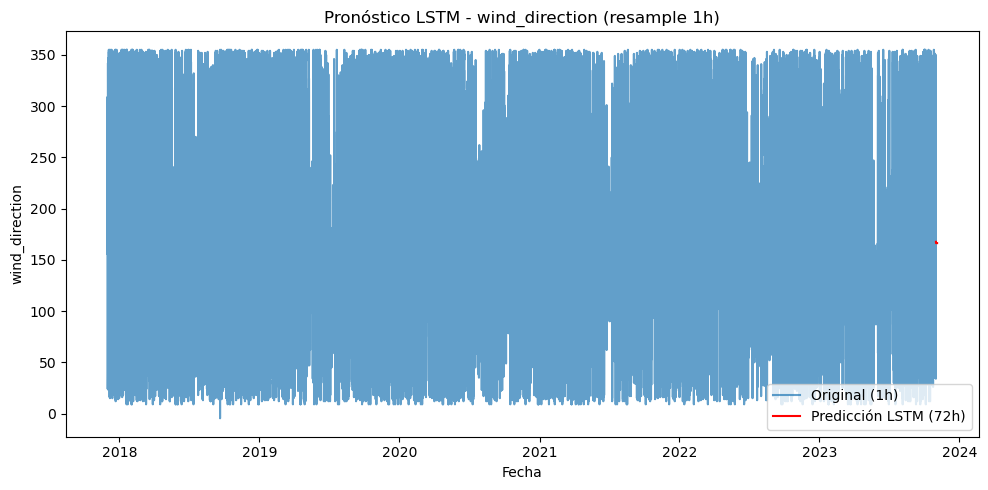

In [ ]:
# PREDICCIÓN CON RED NEURONAL LSTM (NumPy — sin TensorFlow)

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler


class NumpyLSTM:
    """LSTM de una capa + salida densa, implementada solo con NumPy."""

    def __init__(self, hidden_size=32, lr=0.005, seed=42):
        self.hidden_size = hidden_size
        self.lr = lr
        self.rng = np.random.default_rng(seed)
        self._init_weights()

    def _init_weights(self):
        h = self.hidden_size
        scale = 0.05
        self.W = scale * self.rng.standard_normal((4 * h, h + 1))
        self.b = np.zeros(4 * h)
        self.Wy = scale * self.rng.standard_normal((1, h))
        self.by = np.zeros(1)

    @staticmethod
    def _sigmoid(x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

    def _forward_seq(self, seq):
        h = np.zeros(self.hidden_size)
        c = np.zeros(self.hidden_size)
        states = []
        for x_t in seq:
            x_t = float(x_t)
            z = self.W @ np.concatenate([h, [x_t]]) + self.b
            i, f, g, o = np.split(z, 4)
            i, f, o = self._sigmoid(i), self._sigmoid(f), self._sigmoid(o)
            g = np.tanh(g)
            c = f * c + i * g
            h = o * np.tanh(c)
            states.append((h.copy(), c.copy(), i, f, g, o, x_t))
        y = (self.Wy @ h + self.by)[0]
        return y, states

    def fit(self, X, y, epochs=8, batch_size=64):
        n = len(X)
        for _ in range(epochs):
            for batch_idx in np.array_split(self.rng.permutation(n), max(1, n // batch_size)):
                dW = np.zeros_like(self.W)
                db = np.zeros_like(self.b)
                dWy = np.zeros_like(self.Wy)
                dby = np.zeros_like(self.by)
                for j in batch_idx:
                    y_hat, states = self._forward_seq(X[j])
                    err = y_hat - y[j]
                    h_last = states[-1][0]
                    dWy += err * h_last.reshape(1, -1)
                    dby += err
                    dh = err * self.Wy.flatten()
                    dc = np.zeros(self.hidden_size)
                    for h, c, i, f, g, o, x_t in reversed(states):
                        tanh_c = np.tanh(c)
                        do = dh * tanh_c
                        do_raw = do * o * (1 - o)
                        dc = dc + dh * o * (1 - tanh_c ** 2)
                        dg = dc * i
                        dg_raw = dg * (1 - g ** 2)
                        df = dc * c
                        df_raw = df * f * (1 - f)
                        di = dc * g
                        di_raw = di * i * (1 - i)
                        dz = np.concatenate([di_raw, df_raw, dg_raw, do_raw])
                        concat = np.concatenate([h, [x_t]])
                        dW += np.outer(dz, concat)
                        db += dz
                        dh = self.W[:, : self.hidden_size].T @ dz
                        dc = dc * f
                m = len(batch_idx)
                self.W -= self.lr * dW / m
                self.b -= self.lr * db / m
                self.Wy -= self.lr * dWy / m
                self.by -= self.lr * dby / m

    def predict_next(self, seq):
        y, _ = self._forward_seq(seq)
        return y

    def forecast(self, seq, steps):
        seq = list(seq)
        preds = []
        for _ in range(steps):
            nxt = self.predict_next(seq)
            preds.append(nxt)
            seq = seq[1:] + [nxt]
        return np.array(preds)


for col in cols:
    print(f"\n==== Pronóstico con LSTM para {col} ====")

    ts_df = df[[col]].resample("1h").mean().dropna()
    print(f"Puntos tras resample 1h: {len(ts_df):,} (antes: {len(df):,})")

    scaler = MinMaxScaler()
    scaled_values = scaler.fit_transform(ts_df.values)

    seq_len = 24
    X, y = [], []
    for i in range(len(scaled_values) - seq_len):
        X.append(scaled_values[i : i + seq_len, 0])
        y.append(scaled_values[i + seq_len, 0])
    X, y = np.array(X), np.array(y)

    # Usamos las últimas 5 000 secuencias para entrenar más rápido
    max_train = 5000
    if len(X) > max_train:
        X, y = X[-max_train:], y[-max_train:]

    model = NumpyLSTM(hidden_size=32, lr=0.008, seed=42)
    model.fit(X, y, epochs=8, batch_size=64)

    forecast_steps = 72
    last_sequence = scaled_values[-seq_len:, 0]
    forecast_scaled = model.forecast(last_sequence, forecast_steps)
    forecast = scaler.inverse_transform(forecast_scaled.reshape(-1, 1)).flatten()

    last_date = ts_df.index[-1]
    future_dates = pd.date_range(
        last_date + pd.Timedelta(hours=1), periods=forecast_steps, freq="1h"
    )

    # Mostrar solo los últimos 15 días y las predicciones en el plot
    plt.figure(figsize=(10, 5))
    last_15d_start = ts_df.index[-1] - pd.Timedelta(days=15) + pd.Timedelta(hours=1)
    mask = ts_df.index >= last_15d_start
    plt.plot(ts_df.index[mask], ts_df[col][mask], label="Original (últimos 15 días, 1h)", alpha=0.7)
    plt.plot(future_dates, forecast, color="red", label="Predicción LSTM (72h)")
    plt.title(f"Pronóstico LSTM - {col} (últimos 15 días + 72h)")
    plt.xlabel("Fecha")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

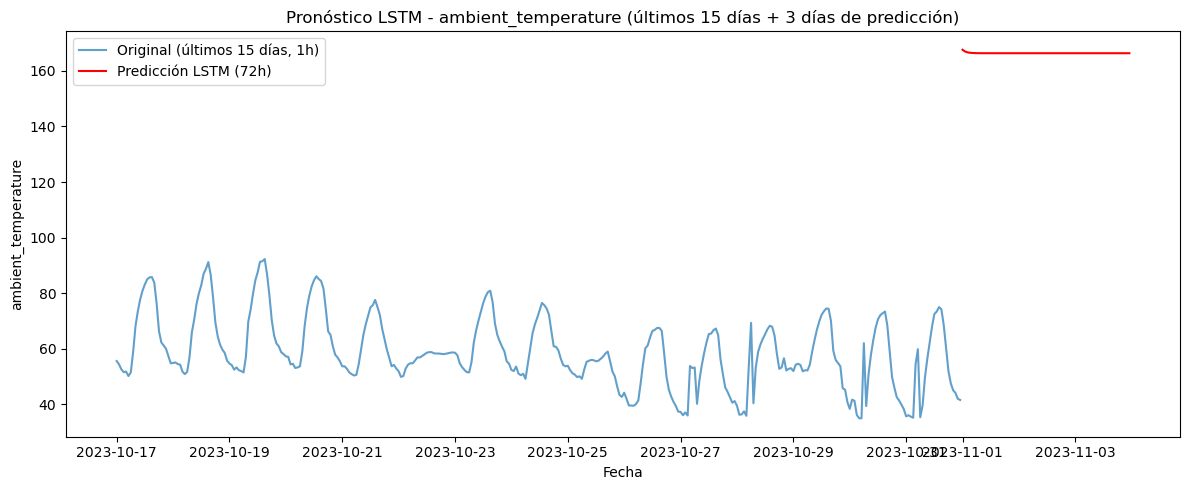

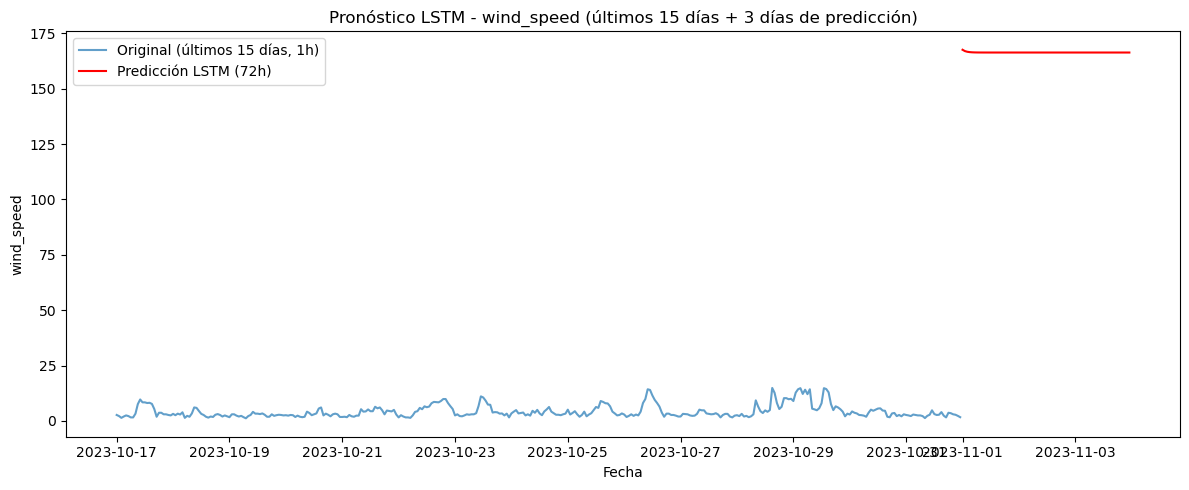

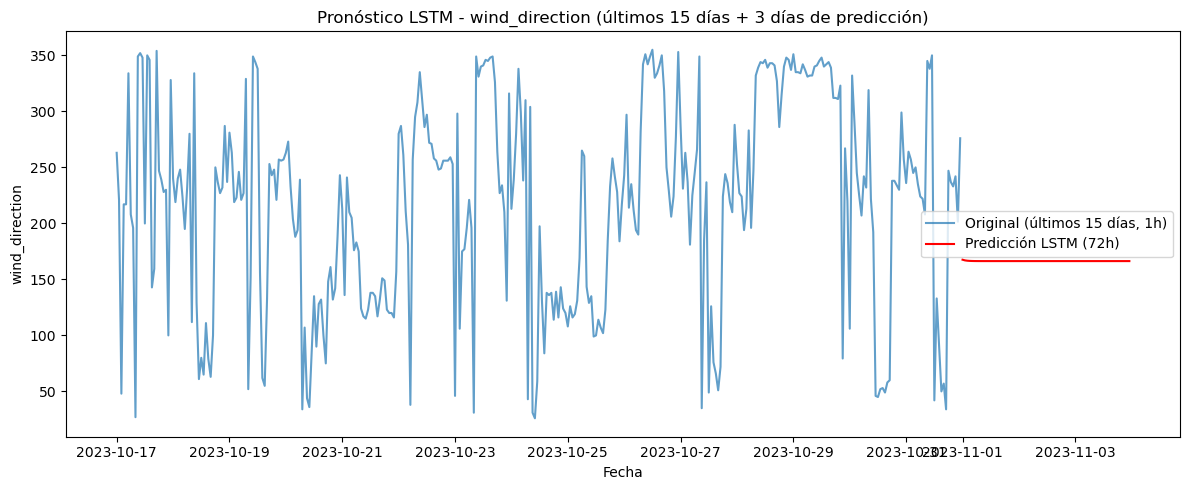

In [18]:
# Graficar últimos 15 días de la serie original y la predicción de 3 días (72 horas) usando los datos y forecasts generados arriba
import matplotlib.pyplot as plt

for idx, col in enumerate(cols):
    ts_df_col = df[[col]].resample("1h").mean().dropna()
    # Determinar los últimos 15 días de la serie
    last_15d_start = ts_df_col.index[-1] - pd.Timedelta(days=15) + pd.Timedelta(hours=1)
    mask = ts_df_col.index >= last_15d_start

    # Prepara forecast (ya generado anteriormente en la celda anterior para cada col)
    forecast_steps = 72
    last_date = ts_df_col.index[-1]
    future_dates = pd.date_range(
        last_date + pd.Timedelta(hours=1), periods=forecast_steps, freq="1h"
    )

    # Graficar
    plt.figure(figsize=(12, 5))
    plt.plot(ts_df_col.index[mask], ts_df_col[col][mask], label="Original (últimos 15 días, 1h)", alpha=0.7)
    plt.plot(future_dates, forecast[:forecast_steps], color="red", label="Predicción LSTM (72h)")
    plt.title(f"Pronóstico LSTM - {col} (últimos 15 días + 3 días de predicción)")
    plt.xlabel("Fecha")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# Comprobar espacio en disco (ejecutar ANTES de instalar TensorFlow)
import shutil

gb_libre = shutil.disk_usage("C:\\").free / (1024 ** 3)
print(f"Espacio libre en C: {gb_libre:.2f} GB")
print("TensorFlow requiere al menos ~3 GB libres para descargar e instalar.\n")

if gb_libre < 3:
    print("No se puede instalar TensorFlow: disco casi lleno.")
    print("La celda LSTM de arriba YA funciona sin TensorFlow (NumPy).")
    print("\nSugerencias para liberar espacio:")
    print("  1. Vaciar Papelera de reciclaje")
    print("  2. %pip cache purge")
    print("  3. Liberar espacio en el disco C:")
else:
    print("Hay espacio suficiente. Instala con:")
    print("  %pip install --upgrade --ignore-installed tensorflow")
    print("Luego reinicia el kernel.")
